<a href="https://colab.research.google.com/github/Anish0089/Employee.attrition/blob/main/Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p data outputs

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving employee_attrition.csv to employee_attrition (2).csv


In [ ]:
!mv employee_attrition.csv data/employee_attrition.csv

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay,
)

sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("data/employee_attrition.csv")
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
print(df["Attrition"].value_counts(normalize=True).round(3), "\n")
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])

for col in ["OverTime", "JobSatisfaction", "WorkLifeBalance", "BusinessTravel"]:
    rate = df.groupby(col)["Attrition"].apply(lambda s: (s == "Yes").mean()).round(3)
    print(f"\nAttrition rate by {col}:\n{rate}")

Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64 

Missing values per column:
 Series([], dtype: int64)

Attrition rate by OverTime:
OverTime
No     0.104
Yes    0.305
Name: Attrition, dtype: float64

Attrition rate by JobSatisfaction:
JobSatisfaction
1    0.228
2    0.164
3    0.165
4    0.113
Name: Attrition, dtype: float64

Attrition rate by WorkLifeBalance:
WorkLifeBalance
1    0.312
2    0.169
3    0.142
4    0.176
Name: Attrition, dtype: float64

Attrition rate by BusinessTravel:
BusinessTravel
Non-Travel           0.080
Travel_Frequently    0.249
Travel_Rarely        0.150
Name: Attrition, dtype: float64


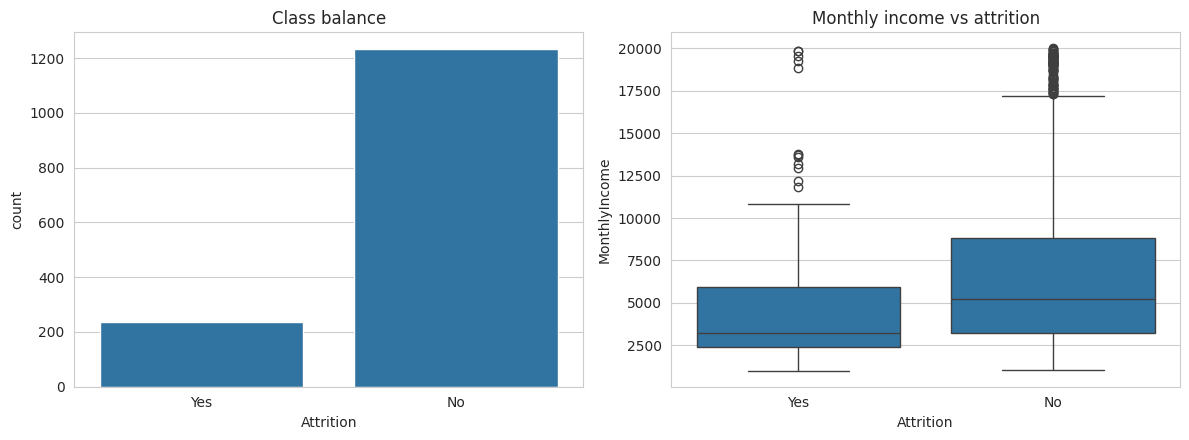

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x="Attrition", ax=axes[0])
axes[0].set_title("Class balance")
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", ax=axes[1])
axes[1].set_title("Monthly income vs attrition")
plt.tight_layout()
plt.show()

In [ ]:
drop_cols = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df_model = df.drop(columns=drop_cols)

target = "Attrition"
y = (df_model[target] == "Yes").astype(int)
X = df_model.drop(columns=[target])

X["TenureRatio"] = X["YearsAtCompany"] / (X["TotalWorkingYears"] + 1)
X["IncomePerYearWorked"] = X["MonthlyIncome"] / (X["TotalWorkingYears"] + 1)
X["PromotionGap"] = X["YearsSinceLastPromotion"] / (X["YearsAtCompany"] + 1)

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

Categorical features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numeric features (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TenureRatio', 'IncomePerYearWorked', 'PromotionGap']


In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


--- Logistic Regression ---
  accuracy  : 0.769
  precision : 0.373
  recall    : 0.660
  f1        : 0.477
  roc_auc   : 0.810
  Confusion matrix [ [TN FP] [FN TP] ]:
  [[195, 52], [16, 31]]

--- Decision Tree ---
  accuracy  : 0.782
  precision : 0.373
  recall    : 0.532
  f1        : 0.439
  roc_auc   : 0.662
  Confusion matrix [ [TN FP] [FN TP] ]:
  [[205, 42], [22, 25]]

--- Random Forest ---
  accuracy  : 0.827
  precision : 0.357
  recall    : 0.106
  f1        : 0.164
  roc_auc   : 0.762
  Confusion matrix [ [TN FP] [FN TP] ]:
  [[238, 9], [42, 5]]


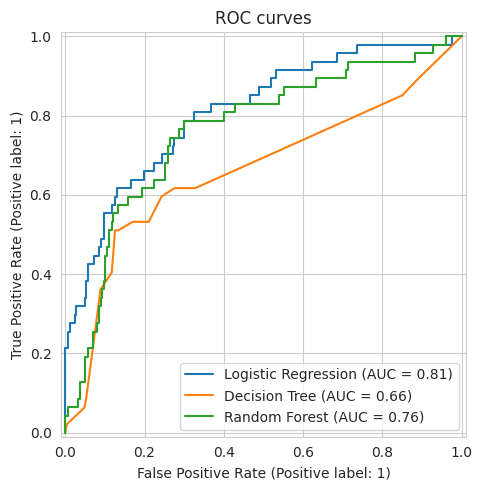

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight="balanced", random_state=42
    ),
}

results = {}
fitted_pipelines = {}

fig, ax = plt.subplots(figsize=(6, 5))
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    results[name] = metrics

    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.3f}")
    print("  Confusion matrix [ [TN FP] [FN TP] ]:")
    print(" ", confusion_matrix(y_test, y_pred).tolist())

    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.set_title("ROC curves")
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(results).T.round(3)
print(results_df)

                     accuracy  precision  recall     f1  roc_auc
Logistic Regression     0.769      0.373   0.660  0.477    0.810
Decision Tree           0.782      0.373   0.532  0.439    0.662
Random Forest           0.827      0.357   0.106  0.164    0.762


             feature  importance
       MonthlyIncome    0.075379
                 Age    0.061145
   TotalWorkingYears    0.049501
      YearsAtCompany    0.046017
        OverTime_Yes    0.045702
 IncomePerYearWorked    0.042736
           DailyRate    0.042470
         TenureRatio    0.042358
         MonthlyRate    0.038571
          HourlyRate    0.036807
    DistanceFromHome    0.036417
YearsWithCurrManager    0.035439
    StockOptionLevel    0.033546
  NumCompaniesWorked    0.031063
  YearsInCurrentRole    0.027334


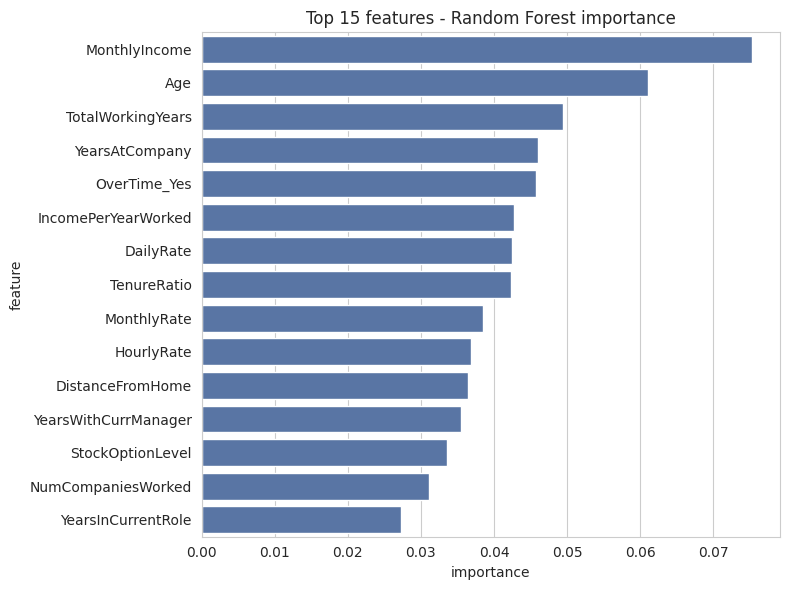

In [ ]:
best_rf = fitted_pipelines["Random Forest"]
feature_names = [f.split("__", 1)[1] for f in best_rf.named_steps["prep"].get_feature_names_out()]
importances = best_rf.named_steps["model"].feature_importances_
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)
print(imp_df.to_string(index=False))

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, y="feature", x="importance", color="#4C72B0")
plt.title("Top 15 features - Random Forest importance")
plt.tight_layout()
plt.show()

                          feature  coefficient
 BusinessTravel_Travel_Frequently     1.664193
                     OverTime_Yes     1.640744
    JobRole_Laboratory Technician     1.521173
     JobRole_Sales Representative     1.239876
        JobRole_Research Director    -1.133512
             EducationField_Other    -1.001775
     BusinessTravel_Travel_Rarely     0.950320
             MaritalStatus_Single     0.828955
          JobRole_Human Resources     0.627404
          YearsSinceLastPromotion     0.620605
                    MonthlyIncome    -0.529981
                         JobLevel     0.503181
     EducationField_Life Sciences    -0.483384
               NumCompaniesWorked     0.480790
Department_Research & Development    -0.421591


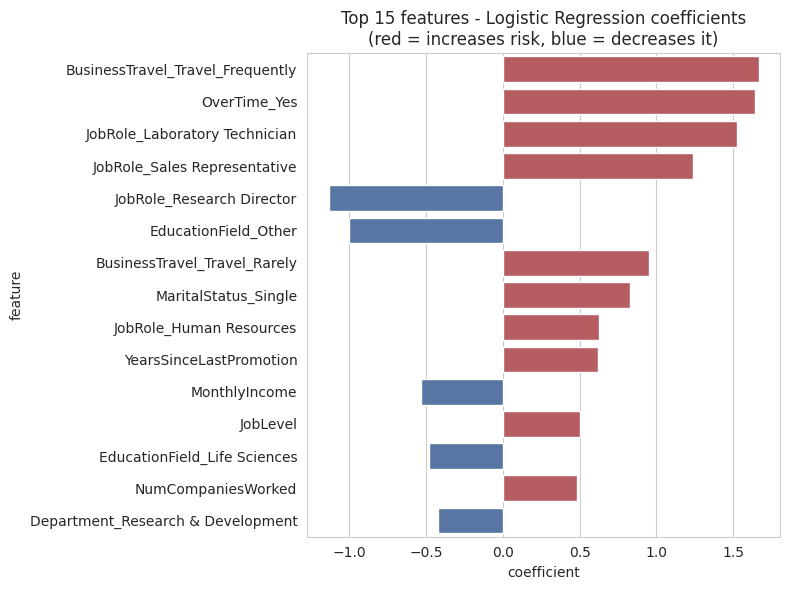

In [ ]:
logreg = fitted_pipelines["Logistic Regression"]
coefs = logreg.named_steps["model"].coef_[0]
coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    .sort_values("coefficient", key=abs, ascending=False)
    .head(15)
)
print(coef_df.to_string(index=False))

plt.figure(figsize=(8, 6))
colors = coef_df["coefficient"].apply(lambda v: "#C44E52" if v > 0 else "#4C72B0")
sns.barplot(data=coef_df, y="feature", x="coefficient", palette=colors.tolist())
plt.title("Top 15 features - Logistic Regression coefficients\n(red = increases risk, blue = decreases it)")
plt.tight_layout()
plt.show()